In [2]:
%pip install librosa

Note: you may need to restart the kernel to use updated packages.


Loading the dataset

In [3]:
import pandas as pd

# Loading the dataset
df = pd.read_csv("ESC-50-master/ESC-50-master/meta/esc50.csv")

# Checking the basic structure of the dataset
print("Shape:", df.shape)
print("\nColumns:",df.columns.tolist())
print("\nFirst five rows")
print(df.head())

Shape: (2000, 7)

Columns: ['filename', 'fold', 'target', 'category', 'esc10', 'src_file', 'take']

First five rows
            filename  fold  target        category  esc10  src_file take
0   1-100032-A-0.wav     1       0             dog   True    100032    A
1  1-100038-A-14.wav     1      14  chirping_birds  False    100038    A
2  1-100210-A-36.wav     1      36  vacuum_cleaner  False    100210    A
3  1-100210-B-36.wav     1      36  vacuum_cleaner  False    100210    B
4  1-101296-A-19.wav     1      19    thunderstorm  False    101296    A


In [4]:
print("\nTotal unique categories:", df['category'].nunique())
print("\nSample counts per category:")
print(df['category'].value_counts())


Total unique categories: 50

Sample counts per category:
category
dog                 40
glass_breaking      40
drinking_sipping    40
rain                40
insects             40
laughing            40
hen                 40
engine              40
breathing           40
crying_baby         40
hand_saw            40
coughing            40
snoring             40
chirping_birds      40
toilet_flush        40
pig                 40
washing_machine     40
clock_tick          40
sneezing            40
rooster             40
sea_waves           40
siren               40
cat                 40
door_wood_creaks    40
helicopter          40
crackling_fire      40
car_horn            40
brushing_teeth      40
vacuum_cleaner      40
thunderstorm        40
door_wood_knock     40
can_opening         40
crow                40
clapping            40
fireworks           40
chainsaw            40
airplane            40
mouse_click         40
pouring_water       40
train               40
sheep        

Filtering the important classes

In [5]:
# Filtering out the only important classes to be used
IMPORTANT_CLASSES = [
    'siren',
    'crying_baby',
    'door_wood_knock',
    'glass_breaking',
    'fireworks',
    'clock_alarm',
    'car_horn',
    'train'
]

# Filtered dataset
df_filtered = df[df['category'].isin(IMPORTANT_CLASSES)].reset_index(drop=True)

# Creating the label map to map text strings to numbers
label_map = {
    'siren': 0,
    'crying_baby': 1,
    'door_wood_knock': 2,
    'glass_breaking': 3,
    'fireworks': 4,
    'clock_alarm': 5,
    'car_horn':6,
    'train': 7
}

# Adding the label column into the filtered dataset
df_filtered['label'] = df_filtered['category'].map(label_map)


print("Filtered samples:", len(df_filtered))
print("\nClass counts:")
print(df_filtered['category'].value_counts())


Filtered samples: 320

Class counts:
category
door_wood_knock    40
fireworks          40
train              40
clock_alarm        40
car_horn           40
crying_baby        40
glass_breaking     40
siren              40
Name: count, dtype: int64


EDA

In [6]:
import librosa
import librosa.display
import matplotlib.pyplot as plt

# Loading only one sample to check if the audio loads correctly or not
filename='ESC-50-master/ESC-50-master/audio/5-260011-A-34.wav'
audio, sr = librosa.load(filename)


c:\Users\rishi\anaconda3\Lib\site-packages\paramiko\pkey.py:82: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "cipher": algorithms.TripleDES,
c:\Users\rishi\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.Blowfish and will be removed from this module in 45.0.0.
  "class": algorithms.Blowfish,
c:\Users\rishi\anaconda3\Lib\site-packages\paramiko\transport.py:243: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "class": algorithms.TripleDES,


In [7]:
# A function that helps us to load the audio in wav plot
import IPython.display as ipd

ipd.Audio(filename)

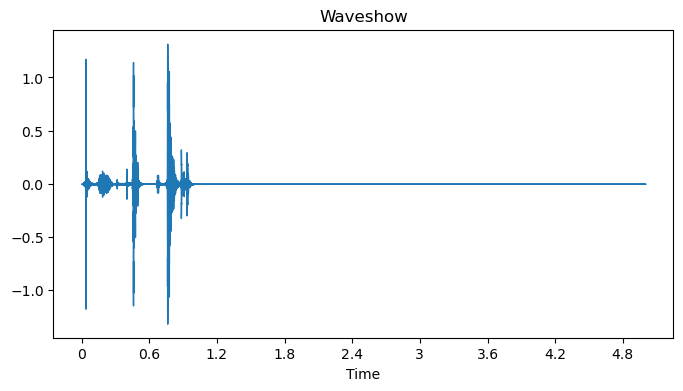

In [8]:
# Generating Waveshow
plt.figure(figsize=(8,4))
librosa.display.waveshow(audio, sr=sr)
plt.title("Waveshow")
plt.show()

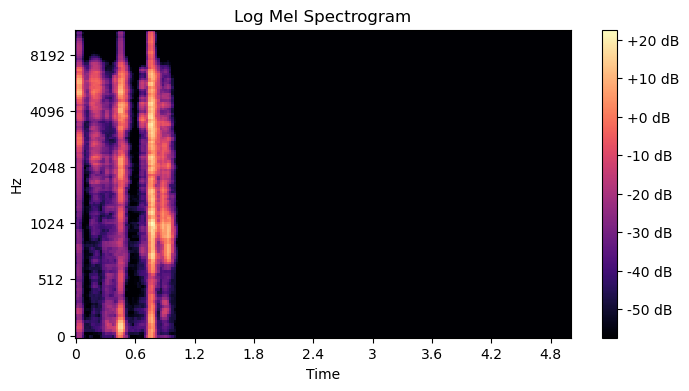

In [9]:
# Generating Log Mel Spectrogram
mel_spec = librosa.feature.melspectrogram(y=audio, sr=sr)
log_mel_spec = librosa.power_to_db(mel_spec)

plt.figure(figsize=(8,4))
librosa.display.specshow(log_mel_spec, sr=sr, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title("Log Mel Spectrogram")
plt.show()

Feature Extraction

Here we extract log mel spectograms from the audio files.

In [10]:
import numpy as np
import librosa

def extract_log_mel_spectrogram(file_path, sr=22050, duration=5, n_mels=128):
    try:
        # Load audio
        audio, sr = librosa.load(file_path, sr=sr, duration=duration)

# Ensure fixed length
        max_len = sr * duration
        if len(audio) < max_len:
            audio = np.pad(audio, (0, max_len - len(audio)),mode='constant')
        else:
            audio = audio[:max_len]


          # Extracts Log Mel Spectrogram
        mel_spec = librosa.feature.melspectrogram(
            y=audio,
            sr=sr,
            n_mels=n_mels,
        )

        log_mel_spec = librosa.power_to_db(mel_spec, ref=np.max)

        return log_mel_spec[..., np.newaxis]

    except Exception as e:
        print(f"Error extracting log-mel spectrogram: {e}")
        return None

Data Augmentation

In [11]:
import numpy as np

def augment_audio(file_path, sr=22050, duration=5, n_mels=128):
  try:
    audio, sr = librosa.load(file_path, sr=sr, duration=duration)

    # Fixing the length of the audio
    max_length = sr * duration
    if len(audio) < max_length:
            audio = np.pad(audio, (0, max_length - len(audio)),mode='constant')
    else:
        audio = audio[:max_length]

    #Randomly choose one augmentation
    choice = np.random.choice(['time_stretch', 'pitch_shift', 'add_noise'])

    if choice == 'time_stretch':
            rate = np.random.uniform(0.85, 1.15)  # speed up by 85 percent or slow down slightly by 115 percent
            stretched_audio = librosa.effects.time_stretch(audio, rate=rate)

          # Refixing the length because time stretching changes the duration
            if len(stretched_audio) < max_length:
                    audio = np.pad(stretched_audio, (0, max_length - len(stretched_audio)),mode='constant')
            else:
                    audio = stretched_audio[:max_length]

    elif choice == 'pitch_shift':
        steps = np.random.uniform(-2, 2)  # shift pitch up or down by up to 2 semitones
        audio = librosa.effects.pitch_shift(audio, sr=sr, n_steps=steps)

    elif choice == 'add_noise':
        noise_level = np.random.uniform(0.001, 0.015)
        noise = np.random.randn(len(audio)) * noise_level
        audio = audio + noise

# Extract log mel spectrogram from augmented audio
    mel_spec = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=n_mels)
    log_mel_spec = librosa.power_to_db(mel_spec,ref=np.max)

    # Fix time dimension to match the original samples(x) which has 216 time steps
    target_time_dimension = 216
    if log_mel_spec.shape[1] < target_time_dimension:
        log_mel_spec = np.pad(log_mel_spec, ((0,0), (0, target_time_dimension - log_mel_spec.shape[1])),mode='constant')
    else:
        log_mel_spec = log_mel_spec[:, :target_time_dimension]

    return log_mel_spec[..., np.newaxis]

  except Exception as e:
    print(f"Error extracting features for {file_path}: {e}")
    return None

print("Augmentation function defined ")

Augmentation function defined 


In [12]:
X = []   # feature arrays
y = []   # string labels


for _, row  in df_filtered.iterrows():
    file_path = "ESC-50-master/ESC-50-master/audio/" + row["filename"]

    # Extracting original spectrogram
    features = extract_log_mel_spectrogram(file_path)
    if features is not None:
        X.append(features)
        y.append(row['category'])

    # Extracting the augmented spectogram
    augment_copies = 2   # number of augmented versions per file
    for _ in range(augment_copies):
        augmented_features = augment_audio(file_path)
        if augmented_features is not None:
            X.append(augmented_features)
            y.append(row['category'])

# Convert to numpy arrays outside the loop
X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (960, 128, 216, 1)
y shape: (960,)


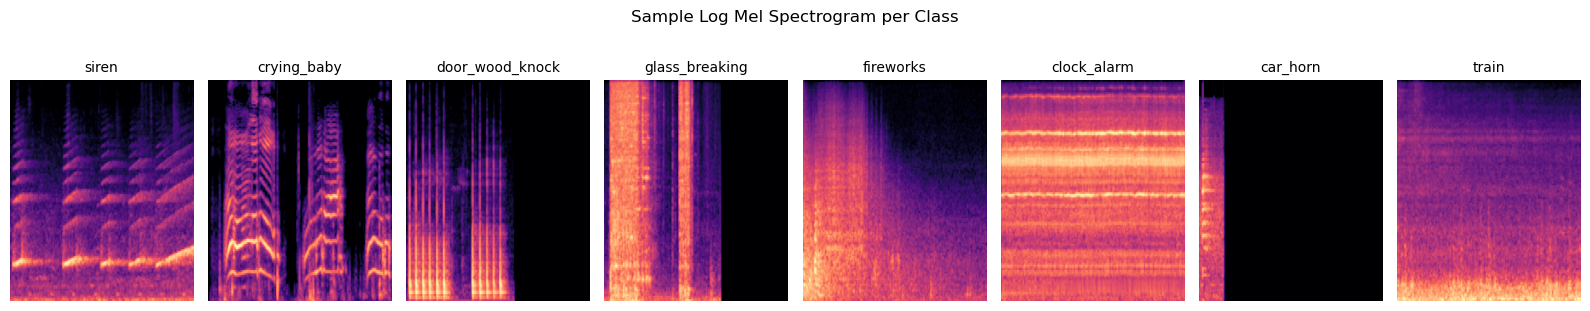

In [13]:
# Visualize one sample from each class after feature extraction
fig, axes = plt.subplots(1, len(IMPORTANT_CLASSES), figsize=(16, 3))
for i, cls in enumerate(IMPORTANT_CLASSES):
    idx = np.where(y == cls)[0][0]
    axes[i].imshow(X[idx, :, :, 0], aspect='auto', origin='lower', cmap='magma')
    axes[i].set_title(cls, fontsize=10)
    axes[i].axis('off')
plt.suptitle('Sample Log Mel Spectrogram per Class', y=1.02)
plt.tight_layout()
plt.show()

Label Encoding and Train Test Split

In [14]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [15]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

# Encode string labels to integers then to one-hot vectors
le        = LabelEncoder()
y_encoded = le.fit_transform(y)           # turning text categories like siren, car_horn into unqiue numbers like 0,1...
y_categorical = to_categorical(y_encoded)

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_categorical,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print(f"\nTrain set : {X_train.shape[0]} samples")
print(f"Test set  : {X_test.shape[0]}  samples")


Train set : 768 samples
Test set  : 192  samples


Normalization

In [17]:
mean = np.mean(X_train)
std  = np.std(X_train)

X_train_norm = (X_train - mean) / std
X_test_norm  = (X_test  - mean) / std

print("Normalization stats (from training set):")
print(f"  Mean : {mean:.4f}")
print(f"  Std  : {std:.4f}")
print()

Normalization stats (from training set):
  Mean : -52.3305
  Std  : 20.0422



In [18]:
print("Before normalization:")
print(f"  Train — Max: {np.max(X_train):.2f}  Min: {np.min(X_train):.2f}")
print("After normalization:")
print(f"  Train — Max: {np.max(X_train_norm):.2f}  Min: {np.min(X_train_norm):.2f}")
print(f"  Train — Mean: {np.mean(X_train_norm):.4f}  (should be ~0)")
print(f"  Train — Std : {np.std(X_train_norm):.4f}   (should be ~1)")

Before normalization:
  Train — Max: 0.00  Min: -80.00
After normalization:
  Train — Max: 2.61  Min: -1.38
  Train — Mean: 0.0000  (should be ~0)
  Train — Std : 1.0000   (should be ~1)


CNN Model

In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input, BatchNormalization)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers

model = Sequential([
    Input(shape=(128,216,1)),
    Conv2D(32, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),


    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),


    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dropout(0.3),

    # Output layer
    Dense(len(IMPORTANT_CLASSES), activation='softmax')
])

In [20]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 216, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 216, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 108, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 108, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 108, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 54, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 54, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 27, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 55296)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,078,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,180,360 (27.39 MB)

 Trainable params: 7,179,912 (27.39 MB)

 Non-trainable params: 448 (1.75 KB)

In [21]:
#Early stopping
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=12,
    restore_best_weights=True
)

history = model.fit(
    X_train_norm, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test_norm, y_test),
    callbacks=[early_stop]
)

Epoch 1/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 25s 929ms/step - accuracy: 0.3385 - loss: 8.1068 - val_accuracy: 0.4531 - val_loss: 2.0888
Epoch 2/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.3581 - loss: 4.0333 - val_accuracy: 0.1979 - val_loss: 4.6128
Epoch 3/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 22s 926ms/step - accuracy: 0.4206 - loss: 2.4549 - val_accuracy: 0.3698 - val_loss: 2.1394
Epoch 4/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 41s 912ms/step - accuracy: 0.4401 - loss: 2.1022 - val_accuracy: 0.1615 - val_loss: 6.7715
Epoch 5/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 23s 961ms/step - accuracy: 0.4896 - loss: 1.7201 - val_accuracy: 0.2135 - val_loss: 4.1984
Epoch 6/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 23s 961ms/step - accuracy: 0.4844 - loss: 1.7101 - val_accuracy: 0.1823 - val_loss: 4.3841
Epoch 7/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 23s 968ms/step - accuracy: 0.5508 - loss: 1.3969 - val_accuracy: 0.2969 - val_loss: 3.3876
Epoch 8/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 23s 951ms/step - accuracy: 0.5417 - loss: 1.2905 - val_accurac

Plotting the training curves

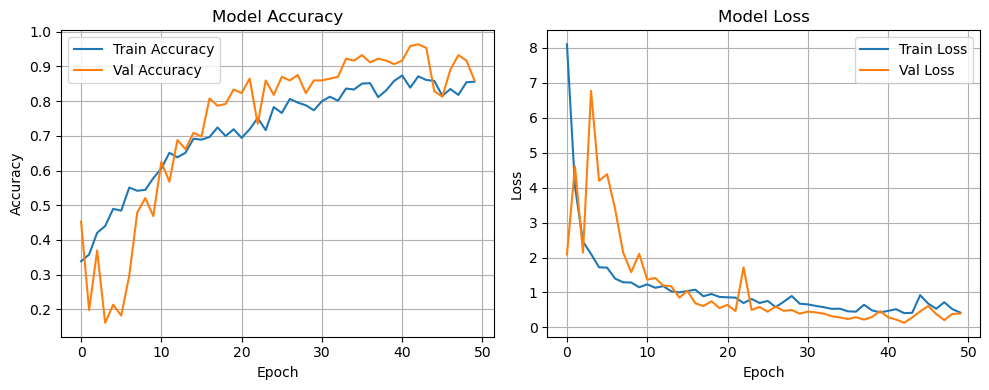

In [25]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Accuracy
ax1.plot(history.history['accuracy'],     label='Train Accuracy')
ax1.plot(history.history['val_accuracy'], label='Val Accuracy')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss
ax2.plot(history.history['loss'],     label='Train Loss')
ax2.plot(history.history['val_loss'], label='Val Loss')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [26]:
#  Confusion matrix + F1 score
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Get predictions
y_pred_probs = model.predict(X_test_norm)
y_pred       = np.argmax(y_pred_probs, axis=1)
y_true       = np.argmax(y_test,       axis=1)

# Classification report (precision, recall, F1 per class)
print("=" * 55)
print("CLASSIFICATION REPORT")
print("=" * 55)
print(classification_report(
    y_true, y_pred,
    target_names=le.classes_
))


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 144ms/step
CLASSIFICATION REPORT
                 precision    recall  f1-score   support

       car_horn       1.00      0.75      0.86        24
    clock_alarm       1.00      1.00      1.00        24
    crying_baby       0.96      1.00      0.98        24
door_wood_knock       1.00      1.00      1.00        24
      fireworks       0.86      1.00      0.92        24
 glass_breaking       0.96      1.00      0.98        24
          siren       1.00      1.00      1.00        24
          train       0.96      0.96      0.96        24

       accuracy                           0.96       192
      macro avg       0.97      0.96      0.96       192
   weighted avg       0.97      0.96      0.96       192



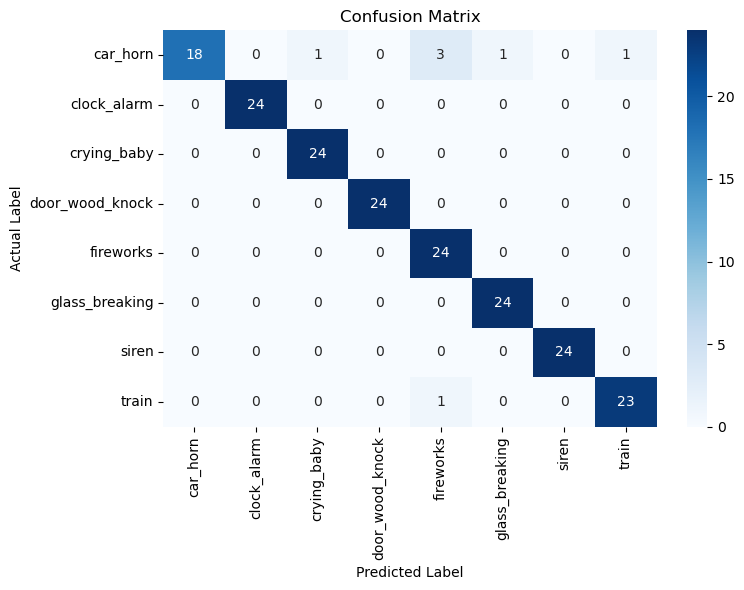

In [27]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()